# TVB Hybrid Simulation – Notebook 4 of 4
## Stochastic Integration and the BOLD Monitor

This notebook demonstrates two features that previously required special
handling in hybrid simulations:

1. **Stochastic integration** — adding additive noise to drive
   subnetwork dynamics and produce more biologically realistic variability.
2. **BOLD monitor** — computing the Balloon–Windkessel haemodynamic
   response from neural activity to produce a simulated fMRI signal.

Both features work out of the box with the hybrid `Simulator` after
configuration of integrator noise and proper monitor initialisation.

**What you'll learn**

- How to create a `HeunStochastic` integrator with additive noise
- How to attach a `Bold` monitor alongside a `TemporalAverage` monitor
- How to extract and visualise neural time series and the simulated BOLD
  signal from a two-subnetwork hybrid simulation

**Setup**: 38-node cortex (JansenRit) + 38-node thalamus
(Generic2dOscillator), connected by bidirectional projections, integrated
with a stochastic Heun scheme.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import scipy.sparse as sp
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

from tvb.simulator.models import JansenRit, Generic2dOscillator
from tvb.simulator.integrators import HeunStochastic, noise
from tvb.simulator.monitors import TemporalAverage, Bold
from tvb.simulator.hybrid import (
    Subnetwork,
    InterProjection,
    NetworkSet,
    Simulator,
)

import tvb.simulator

print("TVB simulator loaded from:", tvb.simulator.__file__)

TVB simulator loaded from: /home/duke/src/tvb-root/tvb_library/tvb/simulator/__init__.py


## 1. Simulation Parameters

We use `HeunStochastic` with additive Gaussian noise (small amplitude to
avoid numerical blow-up).  A shared `dt = 0.1` ms is used by both
subnetworks.

The BOLD monitor requires a much longer simulation to accumulate enough
data for the haemodynamic response function convolution.  We run for
**20 000 ms** (20 s) with a BOLD sampling period of 2 000 ms (2 s),
yielding approximately 10 BOLD samples.

In [2]:
dt = 0.1
nnodes = 38
simulation_length = 20000.0
noise_amplitude = 0.0001

sigma = np.array([(noise_amplitude**2) / 2])
hiss = noise.Additive(nsig=sigma)
scheme = HeunStochastic(dt=dt, noise=hiss)

print(f"dt = {dt} ms | noise σ = {sigma[0]:.2e} | length = {simulation_length} ms")
print(f"Integrator: {scheme.__class__.__name__}")

dt = 0.1 ms | noise σ = 5.00e-09 | length = 20000.0 ms
Integrator: HeunStochastic


## 2. Building the Subnetworks

**JansenRit** (cortex) spontaneously produces alpha-band oscillations.
**Generic2dOscillator** (thalamus) is a 2D phase-plane model that is
numerically robust under stochastic perturbation.

We request 2 variables of interest from each model so the combined
monitor output has 4 VOI rows.

In [3]:
jr_vois = JansenRit.variables_of_interest.default[:2]
g2d_vois = Generic2dOscillator.variables_of_interest.default[:2]

cortex = Subnetwork(
    name="cortex",
    model=JansenRit(variables_of_interest=jr_vois),
    scheme=scheme,
    nnodes=nnodes,
).configure()

thalamus = Subnetwork(
    name="thalamus",
    model=Generic2dOscillator(variables_of_interest=g2d_vois),
    scheme=scheme,
    nnodes=nnodes,
).configure()

print("Cortex model :", cortex.model.__class__.__name__)
print("  state_vars  :", cortex.model.state_variables)
print("  VOIs        :", list(cortex.model.variables_of_interest))
print("Thalamus model:", thalamus.model.__class__.__name__)
print("  state_vars  :", thalamus.model.state_variables)
print("  VOIs        :", list(thalamus.model.variables_of_interest))

Cortex model : JansenRit
  state_vars  : ('y0', 'y1', 'y2', 'y3', 'y4', 'y5')
  VOIs        : ['y0', 'y1']
Thalamus model: Generic2dOscillator
  state_vars  : ('V', 'W')
  VOIs        : ['V']


## 3. Bidirectional Projections

We create two `InterProjection` objects — one from cortex to thalamus
and one back — using a random sparse weight matrix and zero-length
tracts (no conduction delay).  The coupling variable mapping is:

| Projection | Source cvar | Target cvar |
|---|---|---|
| Cortex → Thalamus | `y1` (index 1) | `V` (index 0) |
| Thalamus → Cortex | `V` (index 0) | `y1` (index 1) |

In [4]:
rng = np.random.RandomState(42)
w_dense = np.abs(rng.randn(nnodes, nnodes)) * 0.01
w_sparse = sp.csr_matrix(w_dense)
l_sparse = sp.csr_matrix((nnodes, nnodes))  # zero delays

proj_ctx_thal = InterProjection(
    source=cortex,
    target=thalamus,
    source_cvar=np.array([1]),
    target_cvar=np.array([0]),
    weights=w_sparse,
    lengths=l_sparse,
    cv=1.0,
    dt=dt,
    scale=1e-3,
)

proj_thal_ctx = InterProjection(
    source=thalamus,
    target=cortex,
    source_cvar=np.array([0]),
    target_cvar=np.array([1]),
    weights=w_sparse,
    lengths=l_sparse,
    cv=1.0,
    dt=dt,
    scale=1e-3,
)

for p in [proj_ctx_thal, proj_thal_ctx]:
    p.configure_buffer(
        n_vars_src=p.source.model.nvar,
        n_nodes_src=p.source.nnodes,
        n_modes_src=p.source.model.number_of_modes,
    )

print("Projections configured: cortex↔thalamus (bidirectional)")

Projections configured: cortex↔thalamus (bidirectional)


## 4. Run with TemporalAverage + Bold Monitors

The hybrid `Simulator` handles both monitor types simultaneously:

- `TemporalAverage(period=10.0)` records neural activity every 10 ms.
- `Bold(period=2000.0)` computes the haemodynamic response and outputs
  one BOLD volume every 2 s.

Internally the simulator:
1. Configures integrator noise (`noise.configure_white(dt, shape)`) for
   each stochastic subnetwork during `configure()`.
2. Calls `Bold.compute_hrf()` to initialise the HRF kernel and interim
   stock buffers before allocating the ring buffer.

In [5]:
nets = NetworkSet(
    subnets=[cortex, thalamus],
    projections=[proj_ctx_thal, proj_thal_ctx],
)

tavg = TemporalAverage(period=10.0)
bold_mon = Bold(period=2000.0)

sim = Simulator(
    nets=nets,
    simulation_length=simulation_length,
    monitors=[tavg, bold_mon],
)
sim.configure()

(t_tavg, y_tavg), (t_bold, y_bold) = sim.run()

print(f"TemporalAverage → t: {t_tavg.shape}, y: {y_tavg.shape}")
print(f"BOLD            → t: {t_bold.shape}, y: {y_bold.shape}")

TemporalAverage → t: (2000,), y: (2000, 3, 76, 1)
BOLD            → t: (10,), y: (10, 3, 76, 1)


## 5. Validate Output

We check for NaN and Inf values in both monitor outputs to confirm
numerical stability.

In [6]:
for name, t, y in [("TemporalAverage", t_tavg, y_tavg), ("BOLD", t_bold, y_bold)]:
    n_nan = np.isnan(y).sum()
    n_inf = np.isinf(y).sum()
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    print(f"{name:16s}  NaN={n_nan}  Inf={n_inf}  range=[{y_min:.4f}, {y_max:.4f}]")
    assert n_nan == 0, f"{name} contains {n_nan} NaN values!"
    assert n_inf == 0, f"{name} contains {n_inf} Inf values!"

print("\nNo NaN or Inf values detected — simulation is numerically stable.")

TemporalAverage   NaN=0  Inf=0  range=[-465.4280, 392.9335]
BOLD              NaN=0  Inf=0  range=[-0.9986, 100.8891]

No NaN or Inf values detected — simulation is numerically stable.


## 6. Neural Time Series

The `TemporalAverage` output has shape `(n_time, total_vois, total_nodes, 1)`.
The first 2 VOI rows and first 38 nodes belong to cortex (JansenRit);
the remaining 2 VOI rows and 38 nodes belong to thalamus
(Generic2dOscillator).

In [7]:
n_ctx_vois = len(cortex.model.variables_of_interest)
n_thal_vois = len(thalamus.model.variables_of_interest)

y_ctx = y_tavg[:, :n_ctx_vois, : cortex.nnodes, 0]
y_thal = y_tavg[:, n_ctx_vois:, cortex.nnodes :, 0]

print(f"Cortex array  : {y_ctx.shape}  (time, JR_vois, nodes)")
print(f"Thalamus array: {y_thal.shape}  (time, G2D_vois, nodes)")

Cortex array  : (2000, 2, 38)  (time, JR_vois, nodes)
Thalamus array: (2000, 1, 38)  (time, G2D_vois, nodes)


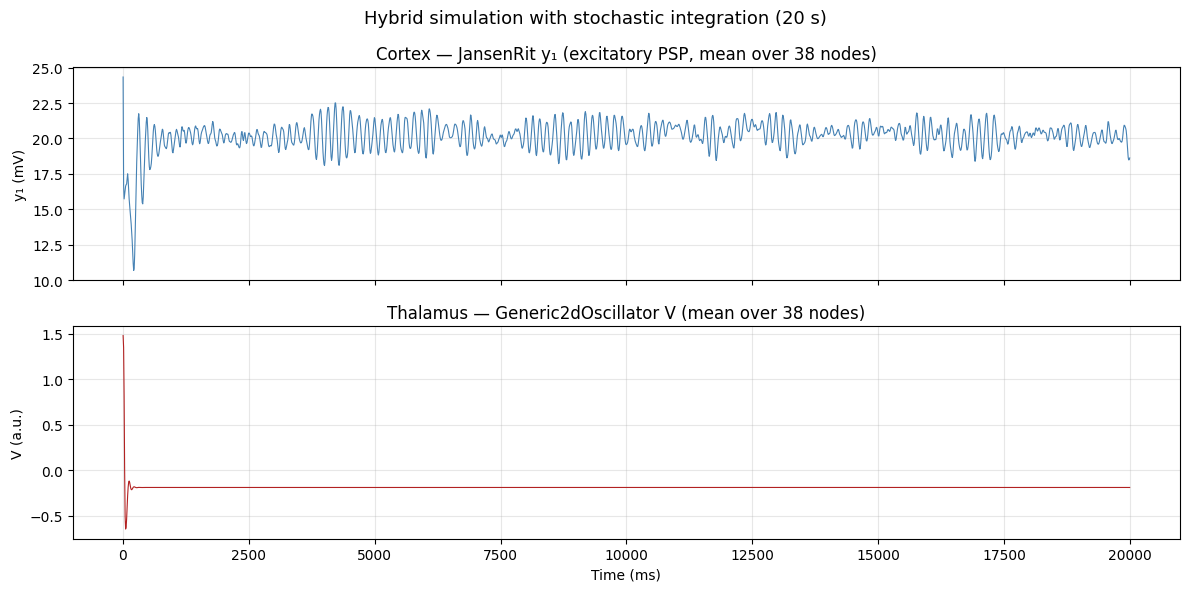

Neural time series plotted.


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Cortex: VOI 1 = y1 (excitatory PSP)
ctx_mean = y_ctx[:, 1, :].mean(axis=1)
axes[0].plot(t_tavg, ctx_mean, linewidth=0.8, color="steelblue")
axes[0].set_ylabel("y₁ (mV)")
axes[0].set_title("Cortex — JansenRit y₁ (excitatory PSP, mean over 38 nodes)")
axes[0].grid(alpha=0.3)

# Thalamus: VOI 0 = V (membrane potential)
thal_mean = y_thal[:, 0, :].mean(axis=1)
axes[1].plot(t_tavg, thal_mean, linewidth=0.8, color="firebrick")
axes[1].set_ylabel("V (a.u.)")
axes[1].set_xlabel("Time (ms)")
axes[1].set_title("Thalamus — Generic2dOscillator V (mean over 38 nodes)")
axes[1].grid(alpha=0.3)

fig.suptitle("Hybrid simulation with stochastic integration (20 s)", fontsize=13)
plt.tight_layout()
plt.savefig("stochastic_neural_timeseries.png", dpi=100, bbox_inches="tight")
plt.show()
print("Neural time series plotted.")

## 7. BOLD Signal

The `Bold` monitor applies a haemodynamic response function (HRF) to
the neural activity and returns one volume every 2 000 ms.  The output
has the same VOI / node layout as the `TemporalAverage` monitor.

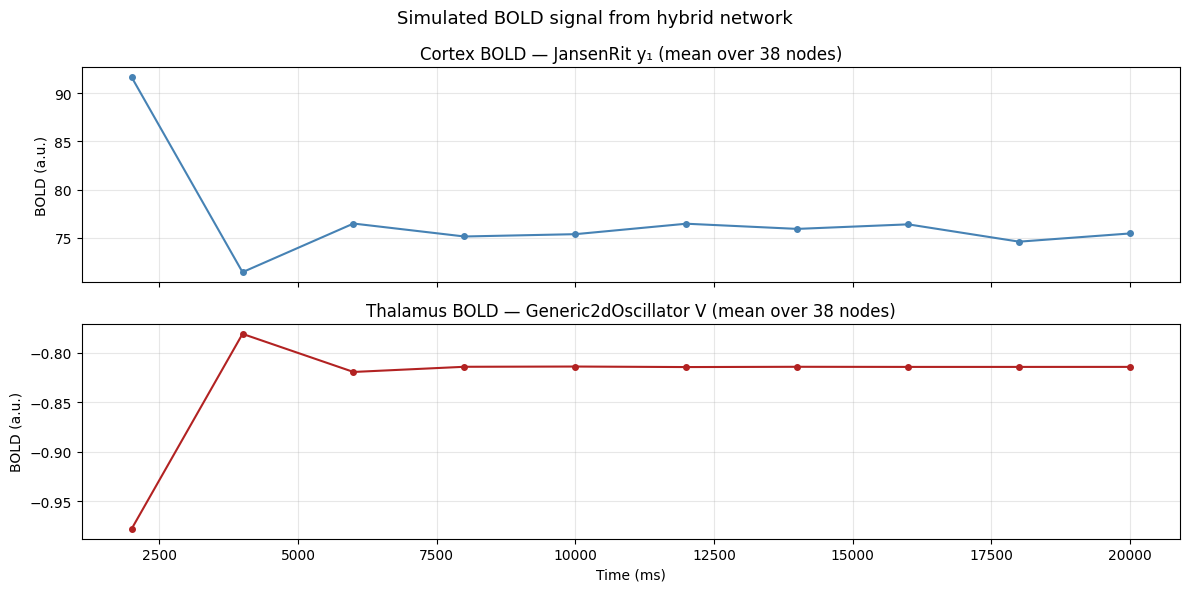

BOLD signal plotted.


In [9]:
n_bold = y_bold.shape[0]
n_ctx_bold = n_ctx_vois
n_thal_bold = n_thal_vois

bold_ctx = y_bold[:, :n_ctx_bold, : cortex.nnodes, 0]
bold_thal = y_bold[:, n_ctx_bold:, cortex.nnodes :, 0]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Cortex BOLD — VOI 1 (y1)
bold_ctx_mean = bold_ctx[:, 1, :].mean(axis=1)
axes[0].plot(
    t_bold, bold_ctx_mean, "o-", linewidth=1.5, markersize=4, color="steelblue"
)
axes[0].set_ylabel("BOLD (a.u.)")
axes[0].set_title("Cortex BOLD — JansenRit y₁ (mean over 38 nodes)")
axes[0].grid(alpha=0.3)

# Thalamus BOLD — VOI 0 (V)
bold_thal_mean = bold_thal[:, 0, :].mean(axis=1)
axes[1].plot(
    t_bold, bold_thal_mean, "o-", linewidth=1.5, markersize=4, color="firebrick"
)
axes[1].set_ylabel("BOLD (a.u.)")
axes[1].set_xlabel("Time (ms)")
axes[1].set_title("Thalamus BOLD — Generic2dOscillator V (mean over 38 nodes)")
axes[1].grid(alpha=0.3)

fig.suptitle("Simulated BOLD signal from hybrid network", fontsize=13)
plt.tight_layout()
plt.savefig("bold_signal.png", dpi=100, bbox_inches="tight")
plt.show()
print("BOLD signal plotted.")

## 8. Individual Node Variability from Stochastic Noise

A key benefit of stochastic integration is that it introduces
trial-to-trial variability that mimics biological noise.  We plot the
cortical y₁ signal for several individual nodes to show the
variability across the network.

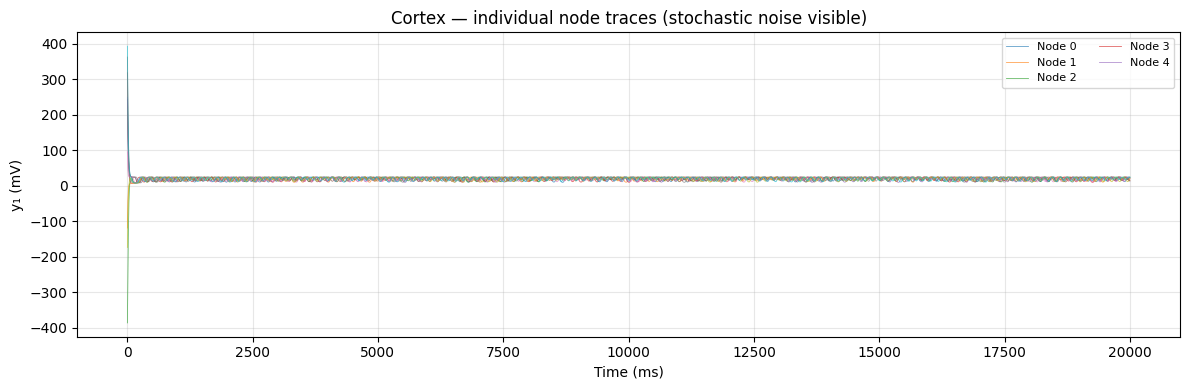

Node variability plotted.


In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(10):
    ax.plot(
        t_tavg,
        y_ctx[:, 1, i],
        linewidth=0.6,
        alpha=0.7,
        color=colors[i],
        label=f"Node {i}" if i < 5 else None,
    )

ax.set_xlabel("Time (ms)")
ax.set_ylabel("y₁ (mV)")
ax.set_title("Cortex — individual node traces (stochastic noise visible)")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stochastic_node_variability.png", dpi=100, bbox_inches="tight")
plt.show()
print("Node variability plotted.")

## 9. Summary

This notebook demonstrated that the hybrid simulation framework now
supports:

- **Stochastic integration** — `HeunStochastic` with additive noise is
  correctly configured (noise `dt` is set during `Subnetwork.configure()`),
  producing trial-variable but numerically stable trajectories.
- **BOLD monitoring** — the `Bold` monitor's haemodynamic response
  function is properly initialised (via `compute_hrf()`) before the
  stock buffer is allocated, so the full Balloon–Windkessel pipeline
  works alongside other monitors in the hybrid simulator.
- **Multi-monitor output** — `TemporalAverage` and `Bold` can be
  attached simultaneously to the same hybrid simulation, returning
  independent `(times, data)` tuples.

**Previous notebooks in the series**

- *Notebook 1* — Getting started with subnetworks and projections.
- *Notebook 2* — Coupling functions, axonal delays, multi-cvar topologies.
- *Notebook 3* — Stimulation, per-subnetwork monitors, connectome-ordered output.